In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
tips=sns.load_dataset('tips')
df=pd.DataFrame(tips)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Exploratory Data Analysis\
Aim: Explore if there is any dependancy betwen the variable tip and the rest of the variables.

sex
Male      157
Female     87
Name: count, dtype: int64


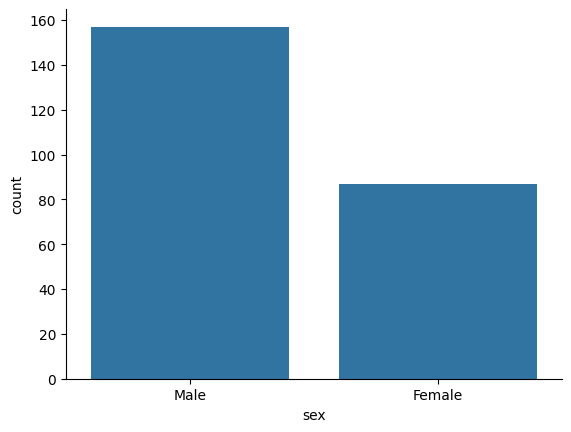

In [9]:
sns.countplot(x='sex',data=tips)
sns.despine()
print(tips.sex.value_counts())

Male customers have given larger number of tips in comparision to female customers.

<Axes: xlabel='sex', ylabel='count'>

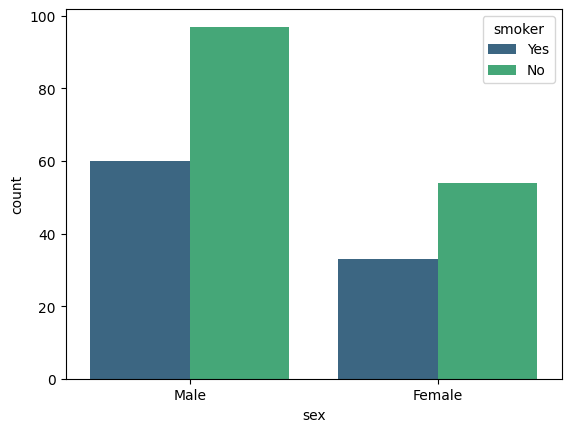

In [10]:
sns.countplot(x='sex', data=tips, hue='smoker', palette='viridis')

Male Non Smokers give more tips in comparision to smokers

<Axes: title={'center': 'Tips Per Day of Week'}, xlabel='day', ylabel='count'>

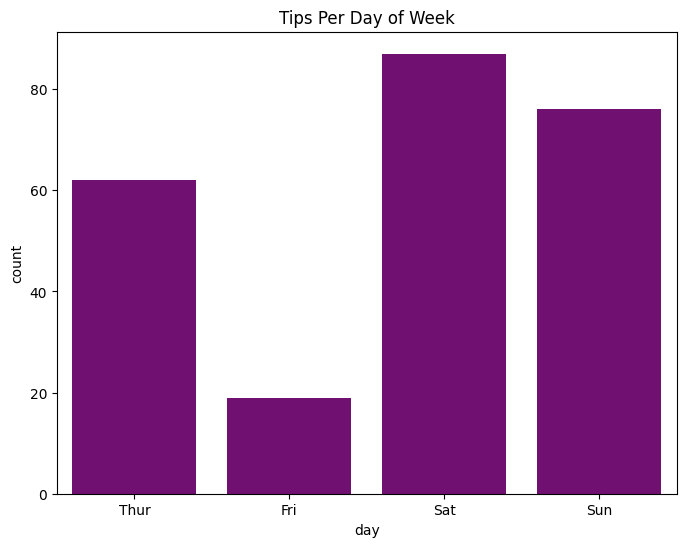

In [11]:
plt.figure(figsize=(8,6))
plt.title('Tips Per Day of Week')
sns.countplot(x=tips['day'], color='purple')

The waiter would prefer to work on saturday as that day the no of tips is high

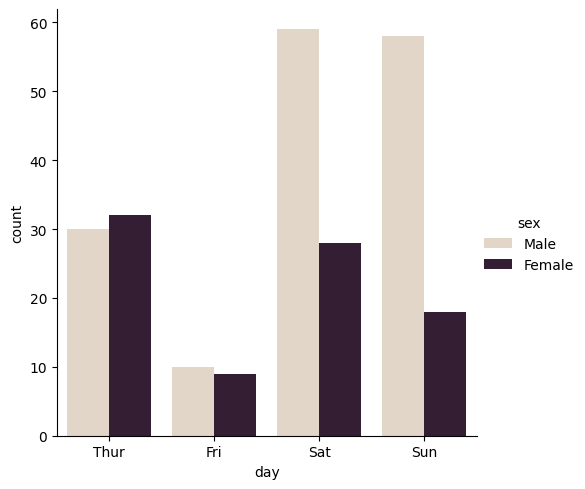

In [12]:
sns.catplot(x='day', data=tips, hue='sex', palette='ch:.25', kind='count')

Would prefer working on Saturday to male customers

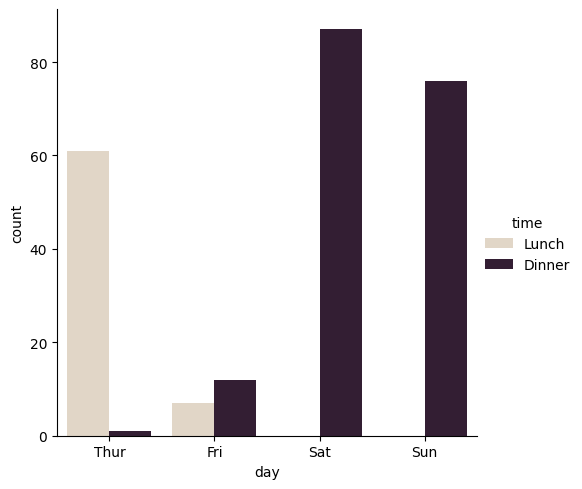

In [13]:
sns.catplot(x='day', data=tips, hue='time', palette='ch:.25', kind='count')

Would prefer serving on sturday for dinner

/tmp/ipython-input-4235560333.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['tip'])


<Axes: xlabel='tip', ylabel='Density'>

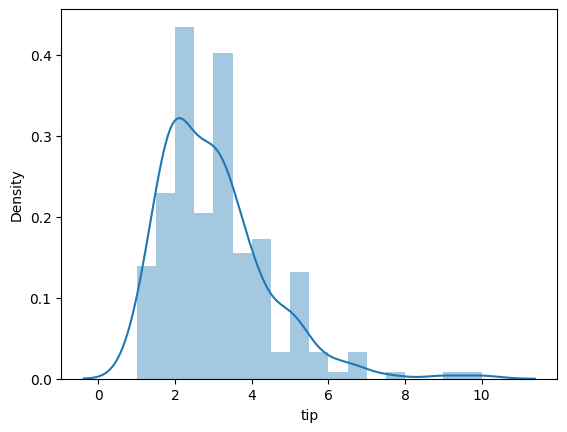

In [16]:
sns.distplot(df['tip'])

Majority of customers have given tips between  to 4 dollars, It is a Right Skewed Distribution with some outliers between 6 to 10 dollars.

/tmp/ipython-input-1792317460.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g=sns.distplot(tips.tip,kde=False)


Text(0.5, 1.0, 'Tip Amount Histogram')

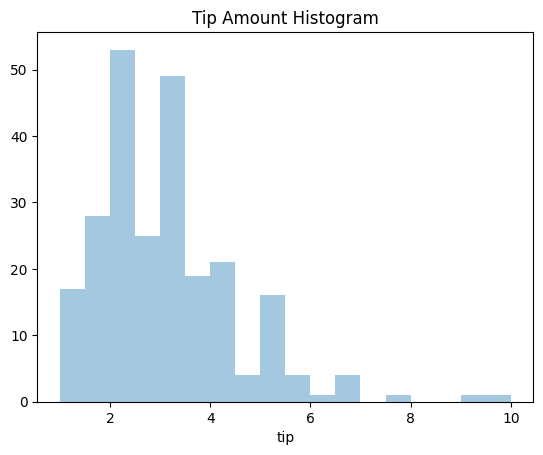

In [18]:
g=sns.distplot(tips.tip,kde=False)
g.set_title("Tip Amount Histogram")

Similar inference as above, kde is false so we do not get the line

<Axes: xlabel='total_bill'>

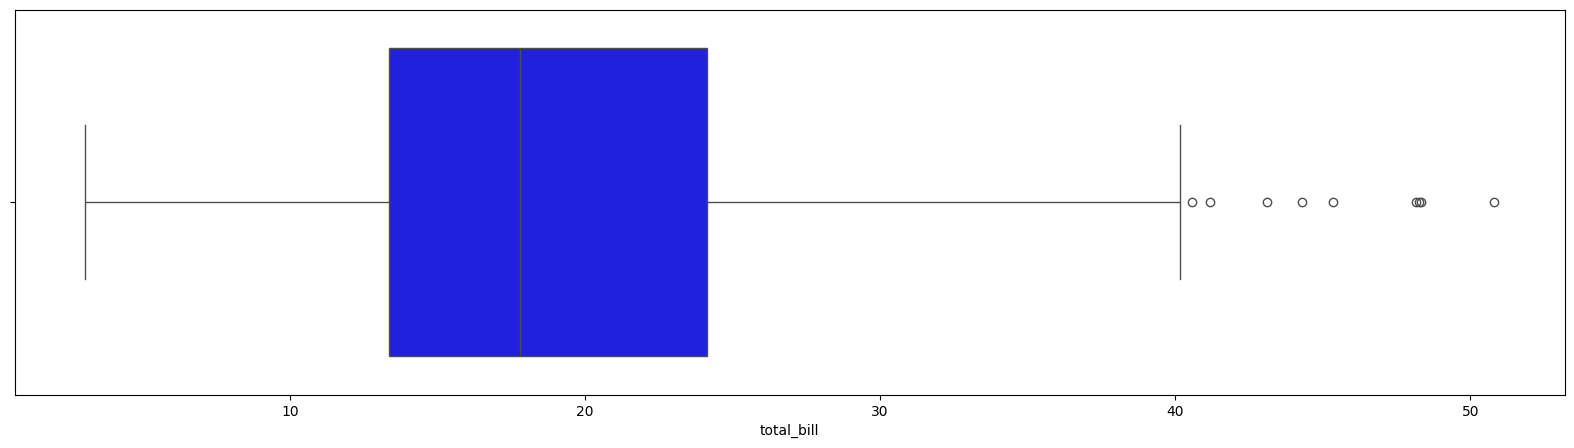

In [23]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df.total_bill, color='b')

There are some outliers in dataset who are customers who have paid more than 40 dollars. 50 percent Customers have bill between 14 to 25 dollars.

<Axes: xlabel='tip'>

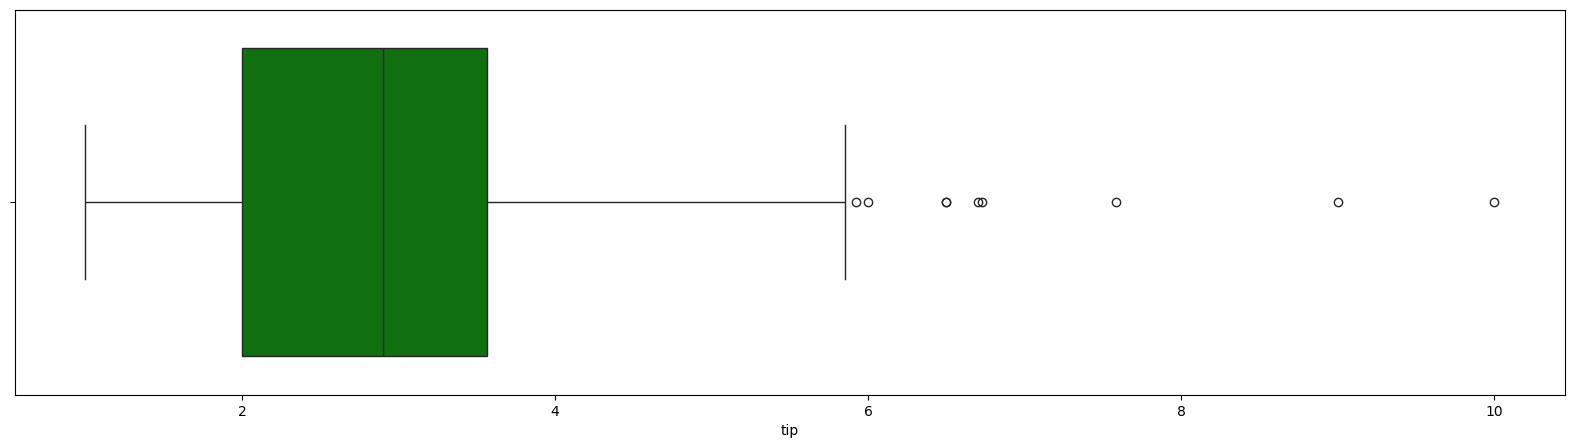

In [26]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df.tip, color='g')

Customers who have given tip beyond 6 dollars are outliers and 50 percent have given between 2 to 3.8 dollars

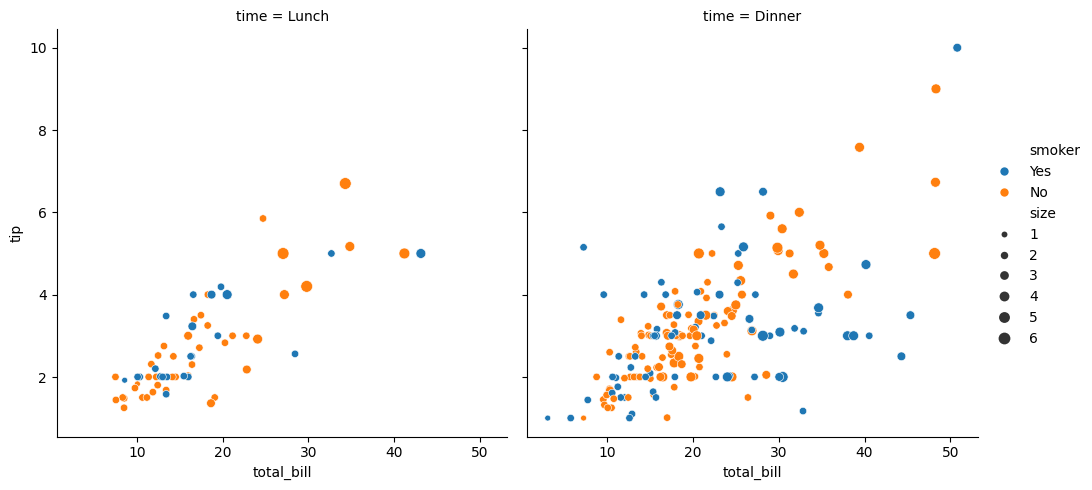

In [28]:
sns.relplot(x='total_bill',y='tip',data=df,col='time',hue='smoker',size='size')

Most of the tips arer during dinner time\
There is Linear relation ship between total bill and tip\
When bill is high non smokwers have given higher amount of tip\
Non smokers with larger group size have given larger amount of tips

<Axes: xlabel='total_bill', ylabel='tip'>

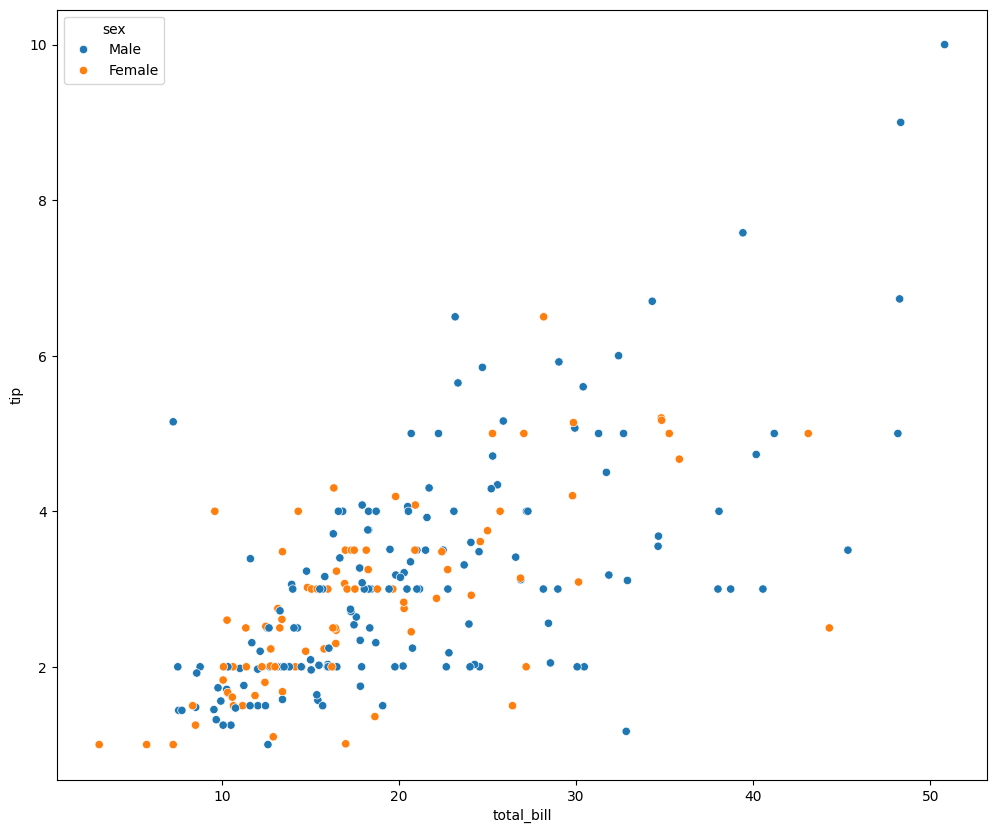

In [29]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=df,x='total_bill',y='tip',hue='sex')

Linear patter as total bill increases tip increases

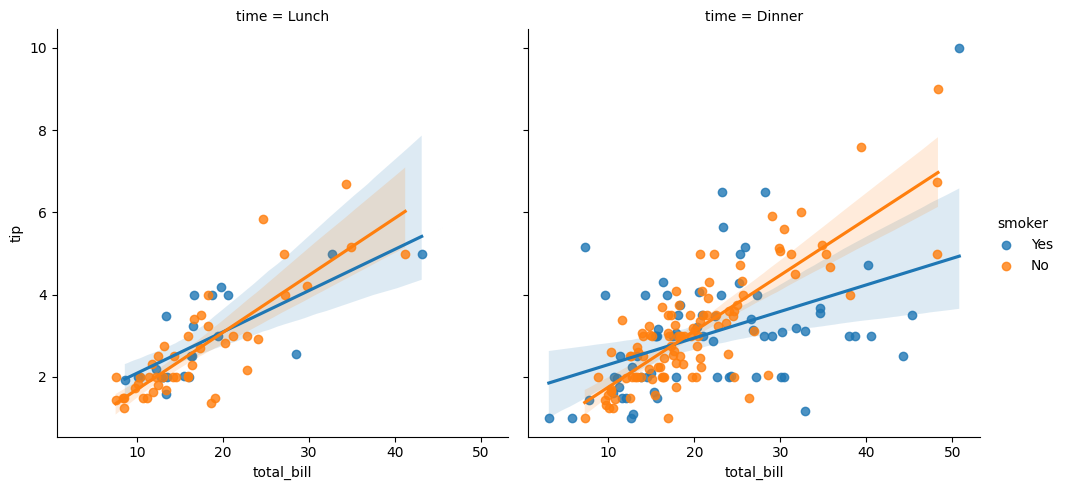

In [30]:
sns.lmplot(x='total_bill',y='tip', data=df, col='time', hue='smoker')

When bill amount is less smokers have given higher tips and when bill amount is high non smokers have given higher tips

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


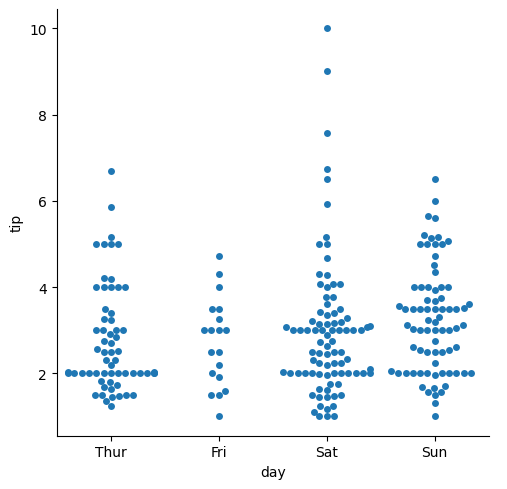

In [31]:
sns.catplot(x='day', y='tip', data=df, kind='swarm')

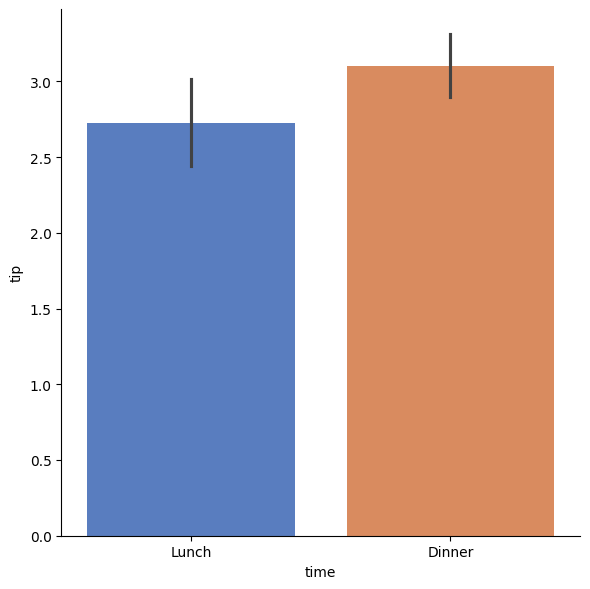

In [34]:
sns.catplot(x='time', y='tip', data=df, height=6, kind='bar', palette="muted")

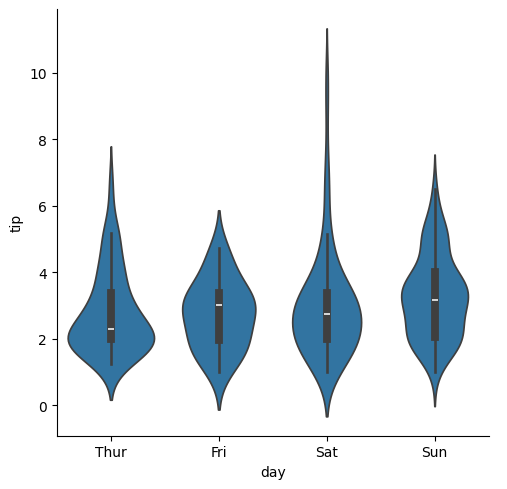

In [32]:
sns.catplot(x='day', y='tip', data=df, kind='violin')

Width of violin shows density and tail of violin shows outliers\
Violin plot is a combination of kde and box plot

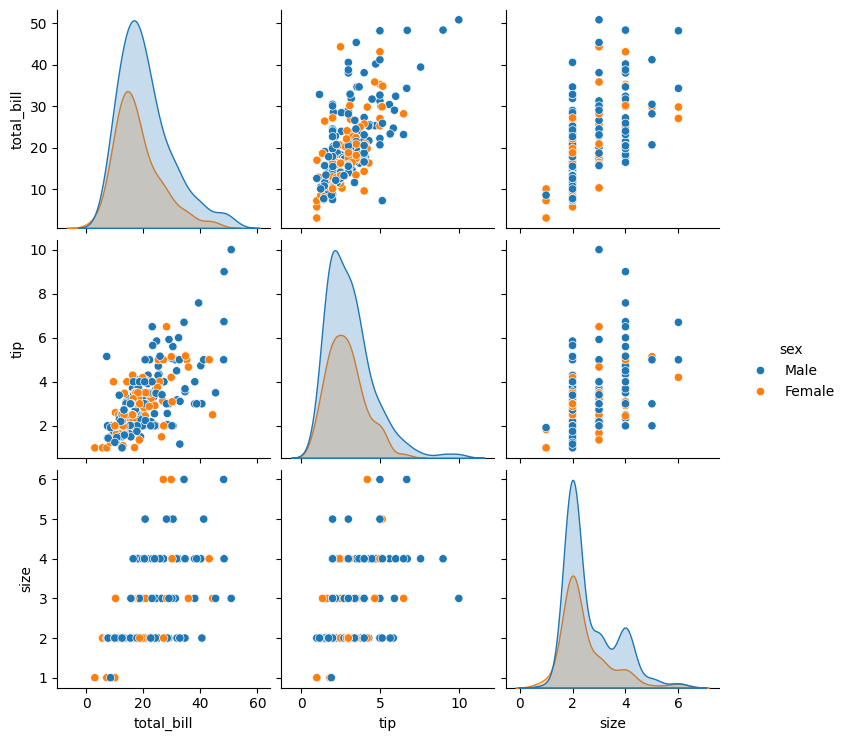

In [35]:
sns.pairplot(df, hue='sex')

Female customers have made highest bills\
Male customers have given larger tips\
Diagonally you get shape of distributionbased on male and female

In [39]:
from ipywidgets import Label
from sklearn.preprocessing import LabelEncoder
labelencoder_df=LabelEncoder()
df['sex']=labelencoder_df.fit_transform(df['sex'])
df['smoker']=labelencoder_df.fit_transform(df['smoker'])
df['day']=labelencoder_df.fit_transform(df['day'])
df['time']=labelencoder_df.fit_transform(df['time'])
df.head

<bound method NDFrame.head of      total_bill   tip  sex  smoker  day  time  size
0         16.99  1.01    0       0    2     0     2
1         10.34  1.66    1       0    2     0     3
2         21.01  3.50    1       0    2     0     3
3         23.68  3.31    1       0    2     0     2
4         24.59  3.61    0       0    2     0     4
..          ...   ...  ...     ...  ...   ...   ...
239       29.03  5.92    1       0    1     0     3
240       27.18  2.00    0       1    1     0     2
241       22.67  2.00    1       1    1     0     2
242       17.82  1.75    1       0    1     0     2
243       18.78  3.00    0       0    3     0     2

[244 rows x 7 columns]>

(7.5, -0.5)

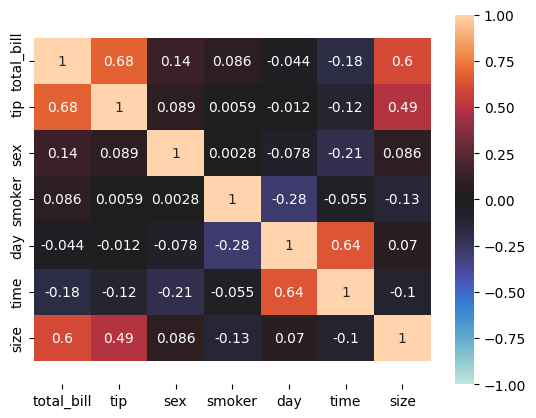

In [40]:
corr_matrix=df.corr()
ax=sns.heatmap(data=corr_matrix, annot=True, vmax=1, vmin=-1,center=0)
bottom, top=ax.get_ylim()
ax.set_ylim(bottom+0.5, top-0.5)

Highesh correlation is between tatal bill and tip followed by total bill and size
Least correlated is day and smoker

Conclusion: The waiter will server a male for dinner on saturday to a non smoker if the bill amount is high and if the bill amount is less then will serve a smoker.